In [84]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [85]:
tangan = cv.imread("tangan.jpg")
tangan_gray = cv.cvtColor(tangan, cv.COLOR_BGR2GRAY)

In [86]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image
tangan_resize = resize(tangan_gray, 256, 256)

In [106]:
sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [ 1,  0],
    [ 0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0,  1],
    [-1,  0]
], dtype=np.float32)

In [ ]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

In [ ]:
def convolution(image, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(image, pad_size, mode='constant')
    canvas   = np.zeros_like(image, dtype=np.float32)

    height, width = image.shape
    for i in range(height):
        for j in range(width):
            region = padded[i : i+size, j : j+size]
            total  = 0.0
            for r in range(size):
                for c in range(size):
                    total += float(region[r, c]) * float(kernel[r, c])
            canvas[i, j] = total

    return canvas

In [89]:
resize_smooth = convolution(tangan_resize, kernelSmoothing)
resize_sharp = convolution(resize_smooth, kernelSharpening)

In [ ]:
def edge(image, kernelx, kernely):
    gx = convolution(image.astype(np.float32), kernelx)
    gy = convolution(image.astype(np.float32), kernely)
    canvas = np.zeros_like(image, dtype=np.float32)

    abs_gx = np.abs(gx)
    abs_gy = np.abs(gy)

    h, w = image.shape
    for i in range(h):
        for j in range(w):
            canvas[i, j] = abs_gx[i, j] + abs_gy[i, j]

    maks = np.max(canvas)
    if maks == 0:
        return np.zeros_like(image, dtype=np.uint8)

    result = np.zeros_like(canvas, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            norm_val = canvas[i, j] * 255.0 / maks
            if   norm_val > 255: result[i, j] = 255
            elif norm_val < 0:   result[i, j] = 0
            else:                result[i, j] = int(norm_val)

    return result

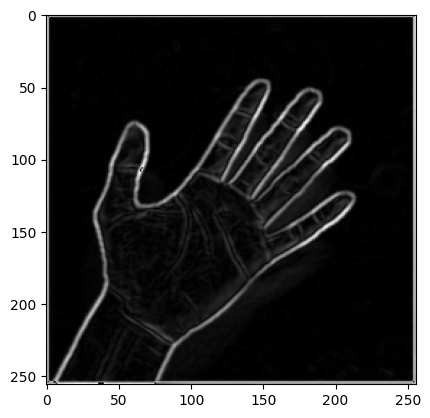

In [107]:
edge_sobel = edge(resize_sharp, sobelX, sobelY)
edge_prewitt = edge(resize_sharp, prewittX, prewittY)
combo = edge_sobel+edge_prewitt
plt.imshow(combo, cmap='gray')

In [ ]:
def threshold(image, batas):
    baris, kolom = image.shape
    canvas = np.zeros_like(image, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if image[i, j] > batas:
                canvas[i, j] = 255
            elif image[i, j] <= batas:
                canvas[i, j] = 0
    return canvas

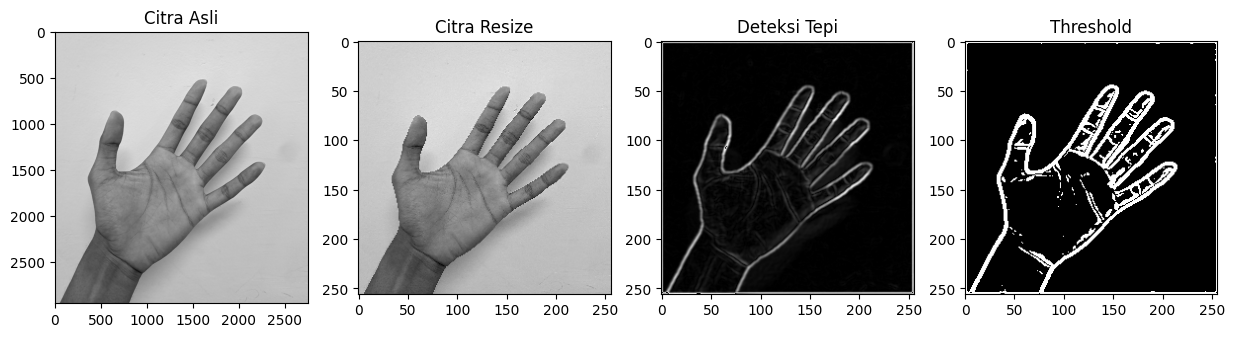

In [ ]:
thres_tangan = threshold(combo, 30)

plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.title("Citra Asli")
plt.imshow(tangan_gray, cmap='gray')
plt.subplot(1,4,2)
plt.title("Citra Resize")
plt.imshow(tangan_resize, cmap='gray')
plt.subplot(1,4,3)
plt.title("Deteksi Tepi")
plt.imshow(combo, cmap='gray')
plt.subplot(1,4,4)
plt.title("Threshold")
plt.imshow(thres_tangan, cmap='gray')

In [118]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

In [95]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

In [124]:
def thinning(image):
    binary = (image > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        hapus = []
   
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))
        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
        hapus = []
   
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))
        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
    return binary * 255

In [ ]:
def thickening(image, kernel, iterasi=1):
    hasil = image.copy()
    for _ in range(iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

In [101]:
def opening(image, kernel):
    hasil_erosi = erosi(image, kernel)
    hasil_opening = dilasi(hasil_erosi, kernel) 
    return hasil_opening

In [102]:
def closing(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_closing = erosi(hasil_dilasi, kernel)
    return hasil_closing

In [103]:
def gradienMorph(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_erosi  = erosi(image, kernel)
    gradient = np.clip(hasil_dilasi.astype(np.int16) - hasil_erosi.astype(np.int16), 0, 255).astype(np.uint8)
    return gradient

Morfologi Citra Kernel 3 x 3

In [133]:
kernel3x3 = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.uint8)

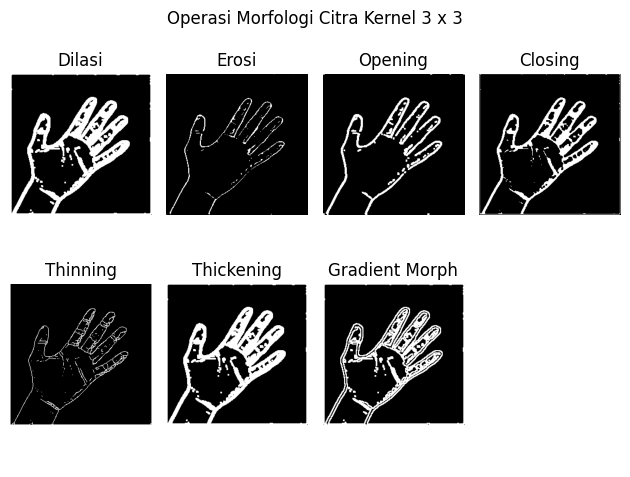

In [142]:
tangan_dilasi = dilasi(thres_tangan, kernel3x3)
tangan_erosi = erosi(thres_tangan, kernel3x3)
tangan_opening = opening(thres_tangan, kernel3x3)
tangan_closing = closing(thres_tangan, kernel3x3)
tangan_thinning = thinning(thres_tangan)
tangan_thickening = thickening(thres_tangan, kernel3x3, 1)
tangan_gradienMorph = gradienMorph(thres_tangan, kernel3x3)

plt.title("Operasi Morfologi Citra Kernel 3 x 3")
plt.axis("off")
plt.subplot(2,4,1)
plt.title("Dilasi")
plt.axis("off")
plt.imshow(tangan_dilasi, cmap='gray')
plt.subplot(2,4,2)
plt.title("Erosi")
plt.axis("off")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2,4,3)
plt.title("Opening")
plt.axis("off")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2,4,4)
plt.title("Closing")
plt.axis("off")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2,4,5)
plt.title("Thinning")
plt.axis("off")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2,4,6)
plt.title("Thickening")
plt.axis("off")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.axis("off")
plt.imshow(tangan_gradienMorph, cmap='gray')
plt.tight_layout()
plt.show()

Morfologi Citra Kernel 5 x 5

In [135]:
kernel5x5 = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
], dtype=np.uint8)

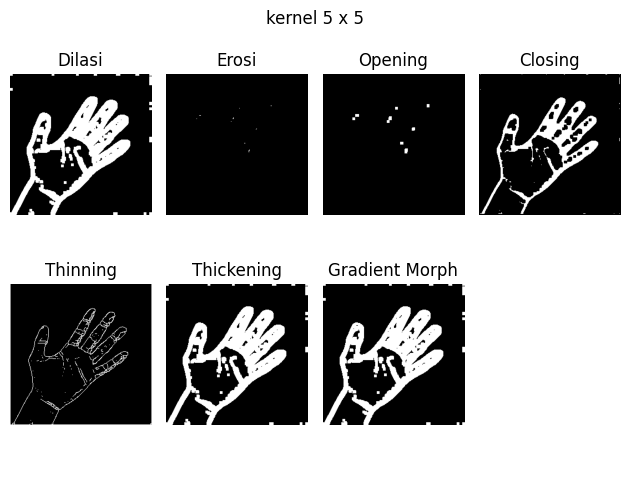

In [ ]:
tangan_dilasi = dilasi(thres_tangan, kernel5x5)
tangan_erosi = erosi(thres_tangan, kernel5x5)
tangan_opening = opening(thres_tangan, kernel5x5)
tangan_closing = closing(thres_tangan, kernel5x5)
tangan_thinning = thinning(thres_tangan)
tangan_thickening = thickening(thres_tangan, kernel5x5, 1)
tangan_gradienMorph = gradienMorph(thres_tangan, kernel5x5)

plt.title("Operasi Morfologi Citra Kernel 5 x 5")
plt.axis("off")
plt.subplot(2,4,1)
plt.title("Dilasi")
plt.axis("off")
plt.imshow(tangan_dilasi, cmap='gray')
plt.subplot(2,4,2)
plt.title("Erosi")
plt.axis("off")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2,4,3)
plt.title("Opening")
plt.axis("off")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2,4,4)
plt.title("Closing")
plt.axis("off")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2,4,5)
plt.title("Thinning")
plt.axis("off")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2,4,6)
plt.title("Thickening")
plt.axis("off")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2,4,7)
plt.title("Gradient Morph")
plt.axis("off")
plt.imshow(tangan_gradienMorph, cmap='gray')
plt.tight_layout()
plt.show()

Kombinasi 2 Proses Morfologi

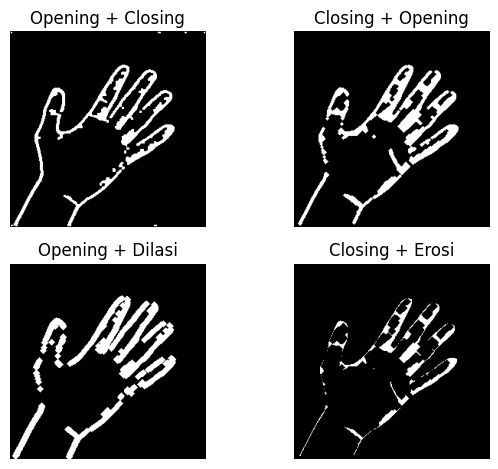

In [ ]:
kombo_open = opening(thres_tangan, kernel3x3)
open_clos = closing(kombo_open, kernel3x3)

kombo_clos = closing(thres_tangan, kernel3x3)
clos_open = opening(kombo_clos, kernel3x3)

kombo_open_dilasi = opening(thres_tangan, kernel3x3)
open_dilasi = dilasi(kombo_open_dilasi, kernel3x3)

kombo_clos_erosi = closing(thres_tangan, kernel3x3)
clos_erosi = erosi(kombo_clos_erosi, kernel3x3)
plt.subplot(2,2,1)
plt.title("Opening + Closing")
plt.axis("off")
plt.imshow(open_clos, cmap='gray')
plt.subplot(2,2,2)
plt.title("Closing + Opening")
plt.axis("off")
plt.imshow(clos_open, cmap='gray')
plt.subplot(2,2,3)
plt.title("Opening + Dilasi")
plt.axis("off")
plt.imshow(open_dilasi, cmap='gray')
plt.subplot(2,2,4)
plt.title("Closing + Erosi")
plt.axis("off")
plt.imshow(clos_erosi, cmap='gray')
plt.tight_layout()
plt.show()

Eksplorasi Mandiri

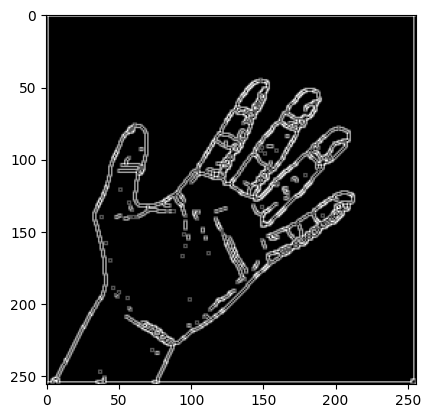

In [ ]:
tangan_eksplor = edge(tangan_thinning, sobelX, sobelY)
plt.imshow(tangan_eksplor, cmap='gray')